# 08 - Customer Churn Risk Classification (Gradient Boosting)

## Business Problem & Context
Predicting which customers are at risk of lapsing over the next 90 days enables marketing teams to trigger proactive win-back email campaigns before the account is permanently lost.

In this notebook, we demonstrate the audited churn classification benchmark, compare 6 candidate models, inspect the selected Gradient Boosting pipeline, and evaluate global SHAP explainability.

### Production Pipeline Traceability
- **Training Script:** `ml/src/models/train_all.py`
- **Saved Model Artifact:** `ml/models/churn_model.joblib`
- **Audited Metrics Report:** `ml/reports/churn_metrics.json`
- **Dashboard Pages:** `Revenue at Risk & Churn` (`RevenueRiskPage.tsx`), `Retention Campaigns` (`RetentionCampaignsPage.tsx`)

In [1]:
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

model_path = os.path.join(PROJECT_ROOT, "ml/models/churn_model.joblib")
metrics_path = os.path.join(PROJECT_ROOT, "ml/reports/churn_metrics.json")
expl_path = os.path.join(PROJECT_ROOT, "ml/reports/explainability.json")

churn_pipeline = joblib.load(model_path)
with open(metrics_path, 'r') as f:
    churn_metrics = json.load(f)
with open(expl_path, 'r') as f:
    expl_data = json.load(f)

print(f"Loaded production churn model: {churn_metrics['best_model_name']}")

Loaded production churn model: Gradient Boosting


## 1. Candidate Model Architecture Benchmark Table
We review the audited evaluation metrics across all 6 evaluated classification algorithms on the ground-truth test cohort.

In [2]:
benchmark_df = pd.DataFrame(churn_metrics['all_models_metrics']).T[['roc_auc', 'pr_auc', 'f1', 'accuracy', 'brier_score']]
benchmark_df.columns = ['ROC-AUC', 'PR-AUC', 'F1 Score', 'Accuracy', 'Brier Score']
benchmark_df.sort_values(by='ROC-AUC', ascending=False)

,ROC-AUC,PR-AUC,F1 Score,Accuracy,Brier Score
Gradient Boosting,0.8313,0.8512,0.8028,0.7661,0.1629
XGBoost,0.8302,0.8492,0.8066,0.768,0.164
LightGBM (Optimised & Calibrated),0.8289,0.8479,0.7965,0.7577,0.1647
Random Forest,0.8209,0.8351,0.7749,0.7446,0.1696
Logistic Regression,0.8162,0.8387,0.7895,0.7446,0.1709
Dummy Baseline,0.5,0.5706,0.7266,0.5706,0.4294


## 2. Confusion Matrix & Global Feature Importance Visualizations

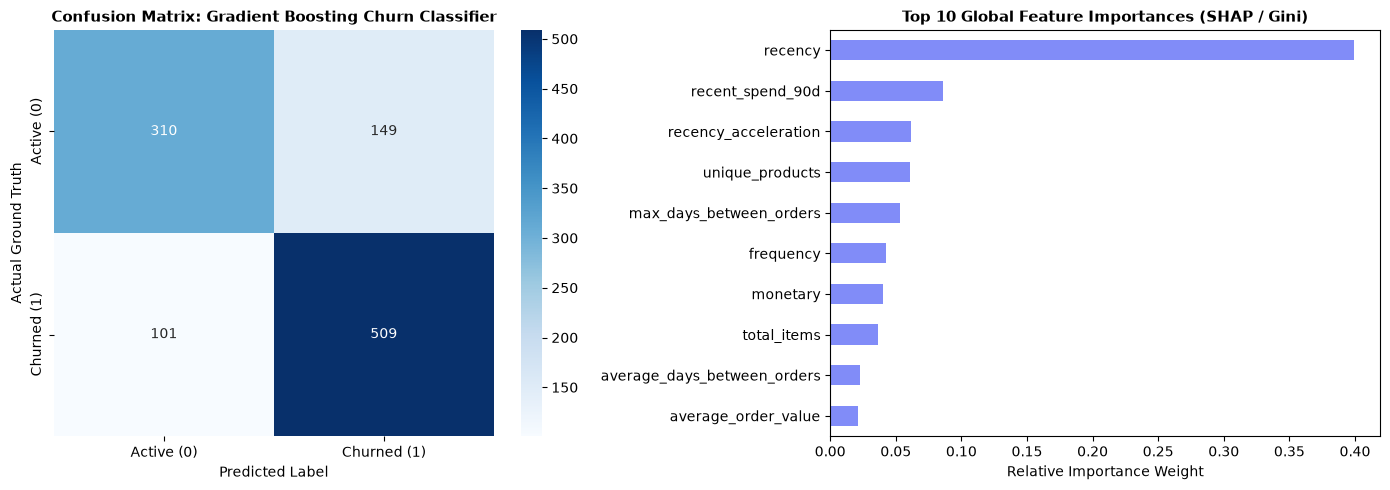

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = np.array(churn_metrics['best_model_metrics']['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active (0)', 'Churned (1)'], yticklabels=['Active (0)', 'Churned (1)'])
axes[0].set_title("Confusion Matrix: Gradient Boosting Churn Classifier", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Ground Truth")

# Top 10 Global Feature Importances
feat_imp = pd.Series(expl_data['global_feature_importances']).sort_values(ascending=True).tail(10)
feat_imp.plot(kind='barh', ax=axes[1], color='#818CF8')
axes[1].set_title("Top 10 Global Feature Importances (SHAP / Gini)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Relative Importance Weight")

plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: Which model achieved the best predictive performance?**
  **A:** **Gradient Boosting Classifier** achieved the highest **ROC-AUC (0.8313)** and **PR-AUC (0.8512)**, outperforming Logistic Regression (0.8162) and Random Forest (0.8209).
- **Q: What is the single most important predictor of churn?**
  **A:** Customer **`recency`** (39.91% global importance weight), followed by `recent_spend_90d` (8.57%) and `recency_acceleration` (6.18%).

### Insights or Next Steps
- Proceed to `09_customer_revenue_prediction.ipynb` to evaluate forward customer spend regression.